In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [17]:
#Simple Linear Regression 
#From: https://www.geeksforgeeks.org/machine-learning/linear-regression-python-implementation/
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

In [18]:
df=pd.read_csv("../DataFrames/tempDF.csv")
df.set_index('t', inplace=True)
print(df.head())


           ds          y
t                       
0  1869-01-01  34.596774
1  1870-01-01  37.693548
2  1871-01-01  27.838710
3  1872-01-01  29.129032
4  1873-01-01  27.354839


Simple LR Coefficients:  [4.53556964e+01 9.39556397e-03]
R2 Score:  0.09658646059797649


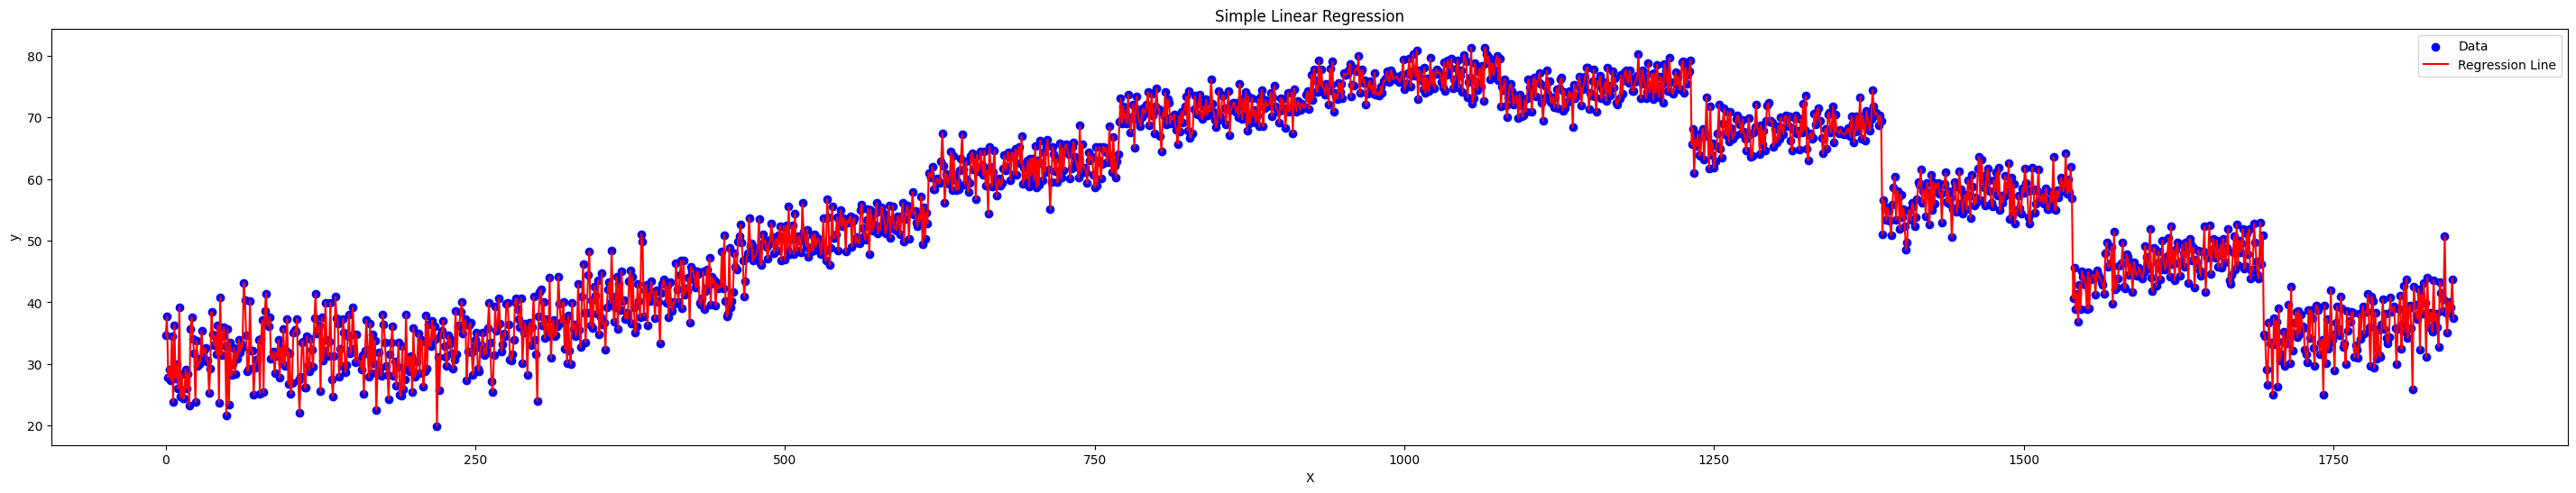

In [19]:
X=np.array(df.index).reshape(-1, 1)
y=np.array(df['y'])

slr=SimpleLinearRegression()
slr.fit(X, y)

print("Simple LR Coefficients: ", slr.coefficients_)
print("R2 Score: ", slr.r2score_)

plt.figure(figsize=(36, 6))

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y, color='red', label='Regression Line')

plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

